In [1]:
# --- Figure 6 notebook header (build-from-source; no cache/pickles) ---
import sys
from pathlib import Path
import pandas as pd, numpy as np, matplotlib.pyplot as plt

here = Path.cwd()
for p in [here, *here.parents]:
    if (p / "utils.py").exists():
        sys.path.insert(0, str(p)); REPO = p; break
import utils
utils.frontiers_style()

# Build all processed data directly from the raw metalearning datasets (~15-20 min)
out = utils.process_all_tasks()

file_names   = list(out['out_agg'].keys())
problem_type = out['problem_type']
scores       = out['scores']
ia_os        = out['ia_os_merge']      # honest nested: select on INNER rank, score on OUTER test
out_agg      = out['out_agg']          # single-loop (biased) comparison

basic_info = utils.load_basic_info()
clf, reg = utils.split_problem_lists(file_names, basic_info)
print(f"built: {len(file_names)} tasks | {len(clf)} clf | {len(reg)} reg | ia_os_merge for {len(ia_os)} tasks")

--- ext_qual_binary
--- ext_qual_failure_mode
--- ext_qual_filament_outcome
--- ext_quant_avg_force
--- ext_quant_avg_force_under4
--- ext_quant_curves
--- ext_quant_max_force
--- ext_quant_max_force_under5
--- ext_quant_stability
--- ext_quant_std_force
--- microgel_formation
--- microgel_init_size
--- microgel_jamming_curves
--- microgel_jamming_curves_over08
--- microgel_shape
--- microgel_size_evolution
--- microgel_size_evolution_under300
--- rheo_osc_plateau_loss
--- rheo_osc_plateau_loss_under20
--- rheo_osc_plateau_storage
--- rheo_osc_plateau_storage_over1000
--- rheo_osc_strain_loss_curves
--- rheo_osc_strain_storage_curves
--- rheo_osc_stress_loss_curves
--- rheo_osc_stress_storage_curves
--- rheo_osc_yield_strain
--- rheo_osc_yield_strain_over10
--- rheo_osc_yield_stress
--- rheo_osc_yield_stress_over20
--- rheo_rot_shear_curves
--- rheo_rot_yield
built: 31 tasks | 14 clf | 17 reg | ia_os_merge for 31 tasks


In [2]:
# ===================== F6 — single-vs-nested bias frames + sanity =====================
GK    = ['iteration', 'outer_k']                          # alignment grain (15 = 3 iter x 5 k)
M1    = {'clf': 'mean_accuracy', 'reg': 'mean_MAE'}       # single-CV score (out_agg)
OUT   = {'clf': 'outer_accuracy', 'reg': 'outer_MAE'}     # nested held-out score (ia_os_merge)
STRAT = [('AS', 'rank_as'), ('HPO', 'rank_hpo'), ('CASH', 'rank_cash')]

rows, diag = [], []
for kind, tasks in [('clf', clf), ('reg', reg)]:
    yi, yo = M1[kind], OUT[kind]
    for S, rp in STRAT:
        rc = f'{rp}_{yi}'
        gk = GK + ['algorithm'] if S == 'HPO' else GK     # HPO = per-algorithm blend (like F5)
        nmatch = nnum = nden = 0
        for t in tasks:
            oa = out_agg[t]; oa = oa[oa.fold == 'test']
            ib = ia_os[t]
            num = oa[oa[rc] == 1].groupby(gk)[yi].mean().rename('single')   # select & score on outer
            den = ib[ib[rc] == 1].groupby(gk)[yo].mean().rename('nested')   # select inner, score outer test
            j = pd.concat([num, den], axis=1)                              # index-aligned join
            matched = j.dropna()
            nnum += int(num.notna().sum()); nden += int(den.notna().sum()); nmatch += len(matched)
            r = matched['single'] / matched['nested']
            rows.append(pd.DataFrame({'task': t, 'kind': kind, 'strategy': S, 'ratio': r.values}))
        diag.append((kind, S, nmatch, nnum, nden))

bias = pd.concat(rows, ignore_index=True)
bias['strategy'] = pd.Categorical(bias['strategy'], ['AS', 'HPO', 'CASH'], ordered=True)

# ---- sanity ----
print("ALIGNMENT INTEGRITY (matched should equal both num & den group counts):")
for kind, S, nm, nn, nd in diag:
    flag = '' if (nm == nn == nd) else '   <-- MISALIGN, investigate'
    print(f"  [{kind:3s} {S:4s}] matched={nm}  num={nn}  den={nd}{flag}")
print("\nSINGLE ÷ NESTED optimism bias  (clf >1 = optimistic accuracy; reg <1 = optimistic MAE):")
print(bias.groupby(['kind', 'strategy'], observed=True)['ratio'].agg(['median', 'mean', 'count']).round(4))

ALIGNMENT INTEGRITY (matched should equal both num & den group counts):
  [clf AS  ] matched=210  num=210  den=210
  [clf HPO ] matched=1470  num=1470  den=1470
  [clf CASH] matched=210  num=210  den=210
  [reg AS  ] matched=255  num=255  den=255
  [reg HPO ] matched=1785  num=1785  den=1785
  [reg CASH] matched=255  num=255  den=255

SINGLE ÷ NESTED optimism bias  (clf >1 = optimistic accuracy; reg <1 = optimistic MAE):
               median    mean  count
kind strategy                       
clf  AS        1.0186  1.0280    210
     HPO       1.0364  1.0464   1470
     CASH      1.0468  1.0592    210
reg  AS        0.9613  0.9152    255
     HPO       0.9432  0.9174   1785
     CASH      0.8888  0.8356    255


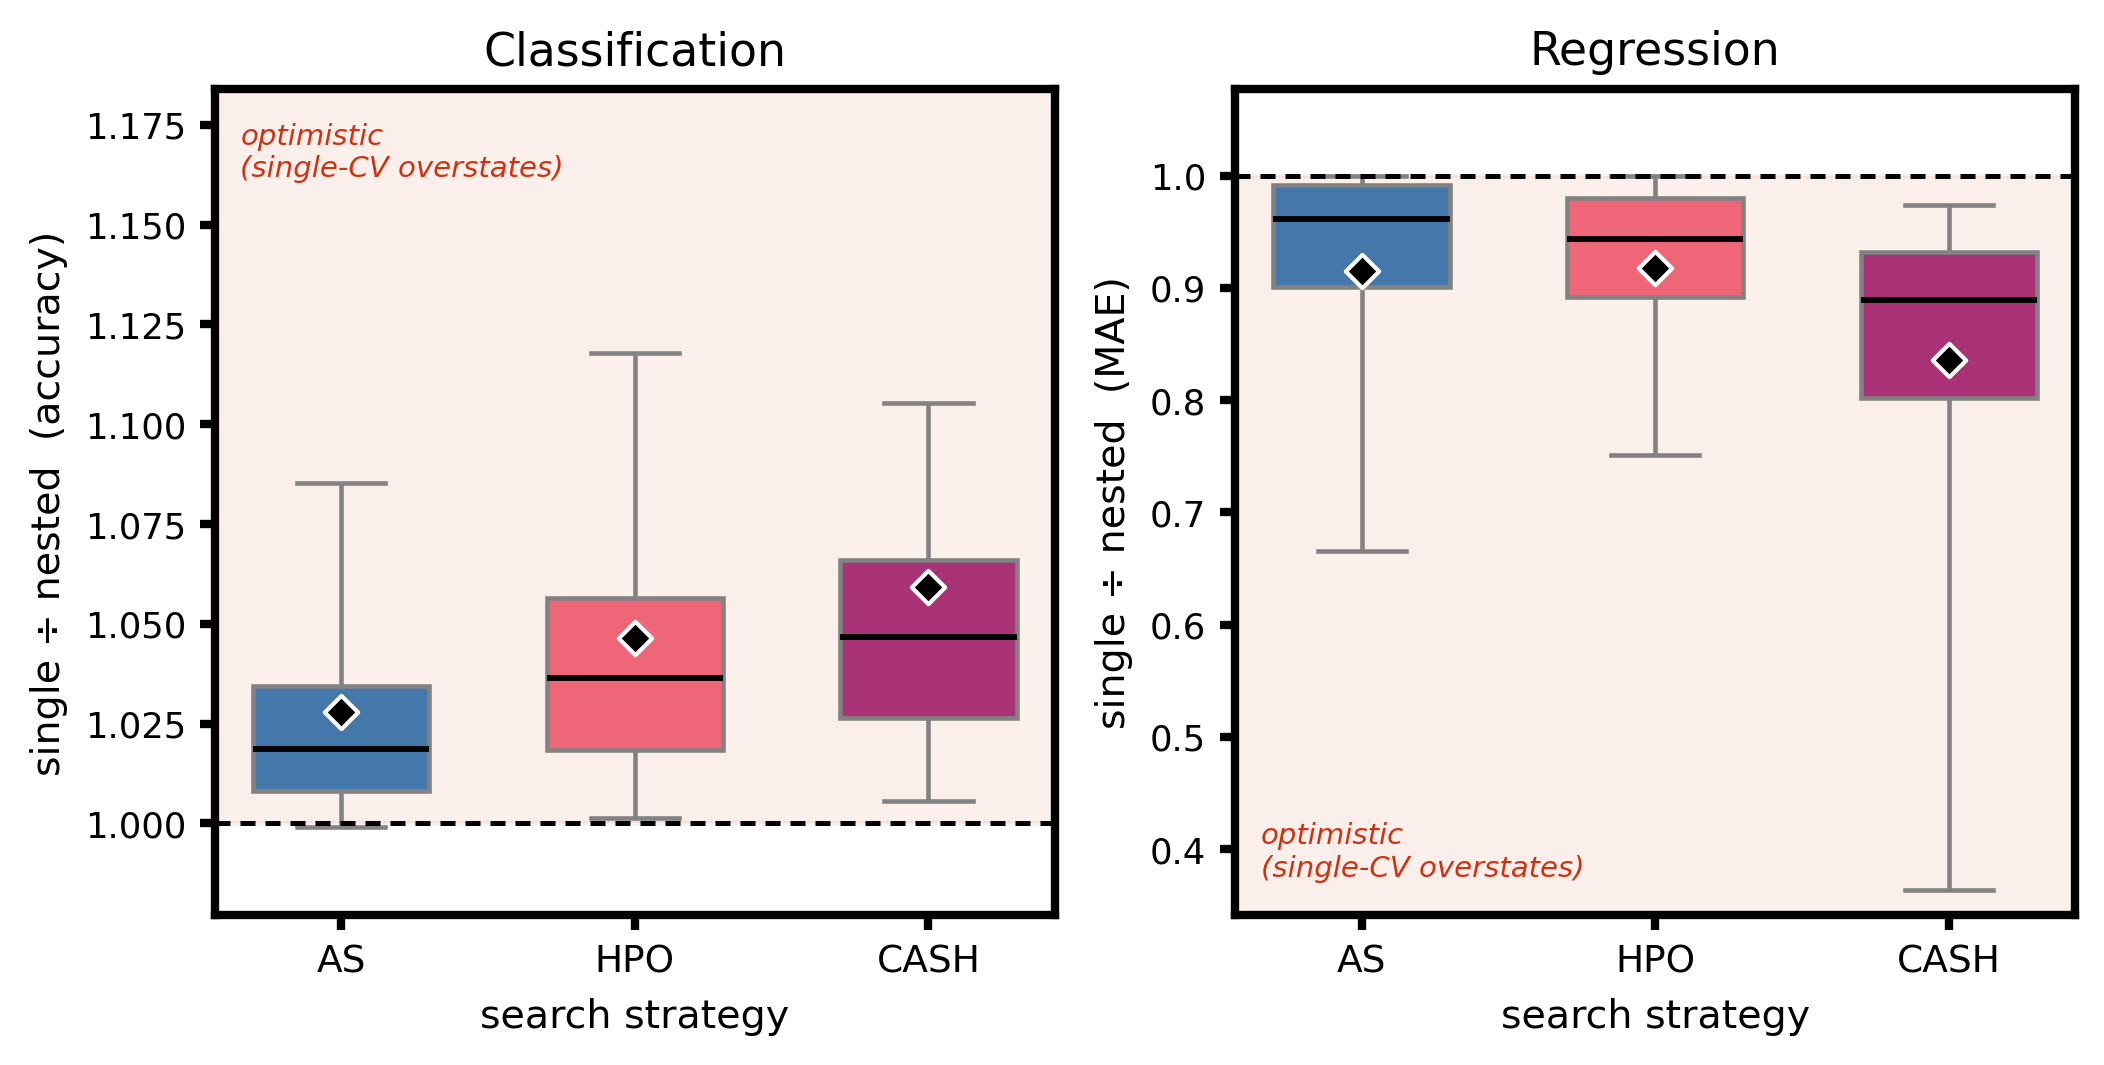

In [3]:
# ===================== F6 — figure (single ÷ nested bias, per strategy) =====================
import seaborn as sns
plt.rcParams.update({
    'axes.linewidth': 2.0, 'font.size': 9, 'axes.titlesize': 11, 'axes.labelsize': 9.5,
    'xtick.labelsize': 9, 'ytick.labelsize': 8.5, 'xtick.major.width': 2.0, 'ytick.major.width': 2.0,
    'pdf.fonttype': 42, 'ps.fonttype': 42,
})
STRAT_ORDER = ['AS', 'HPO', 'CASH']
STRAT_PAL = {'AS':'#4477AA', 'HPO':'#EE6677', 'CASH':'#AA3377'}   # matches F5
RED = '#CC3311'

fig, axes = plt.subplots(1, 2, figsize=(180/25.4, 92/25.4))
for ci, kind in enumerate(['clf', 'reg']):
    ax = axes[ci]; d = bias[bias.kind == kind]
    sns.boxplot(data=d, x='strategy', y='ratio', order=STRAT_ORDER, ax=ax, whis=(5,95),
                showfliers=False, width=0.6, color='0.85', linewidth=1.1,
                medianprops=dict(color='black', lw=1.4))
    for p, s in zip(ax.patches, STRAT_ORDER): p.set_facecolor(STRAT_PAL[s])
    means = d.groupby('strategy', observed=True)['ratio'].mean().reindex(STRAT_ORDER)
    ax.scatter(range(3), means.values, marker='D', s=32, color='black', edgecolor='white', lw=1.0, zorder=10)
    lo, hi = np.nanpercentile(d['ratio'], [2, 98]); lo = min(lo, 1.0); hi = max(hi, 1.0)
    pad = (hi - lo) * 0.12; lo, hi = lo - pad, hi + pad
    ax.set_ylim(lo, hi)
    # optimistic region (native direction): clf ratio>1, reg ratio<1
    ax.axhspan(1.0, hi, color=RED, alpha=0.08, zorder=0) if kind == 'clf' else \
        ax.axhspan(lo, 1.0, color=RED, alpha=0.08, zorder=0)
    ax.axhline(1.0, color='black', lw=1.2, ls=(0,(3,2)), zorder=3)   # honest (nested)
    ax.annotate('optimistic\n(single-CV overstates)',
                xy=(0.03, 0.96 if kind == 'clf' else 0.04), xycoords='axes fraction',
                va='top' if kind == 'clf' else 'bottom', ha='left', fontsize=7, color=RED, style='italic')
    ax.set_xticks(range(3)); ax.set_xticklabels(STRAT_ORDER); ax.set_xlabel('search strategy')
    ax.set_title('Classification' if kind == 'clf' else 'Regression', fontsize=11, pad=6)
    ax.set_ylabel('single ÷ nested  (accuracy)' if kind == 'clf' else 'single ÷ nested  (MAE)')
fig.tight_layout()

In [5]:
from pathlib import Path
figdir = REPO / "figures"; figdir.mkdir(exist_ok=True)
fig.savefig(figdir / "Figure6_nesting.pdf", dpi=300, bbox_inches='tight')
fig.savefig(figdir / "Figure6_nesting.png", dpi=300, bbox_inches='tight')  # for quick viewing
print("saved to", figdir)

saved to C:\Users\conno\Documents\GitHub\ML_MetaLearning_SoftMatter\figures
